In [7]:
#pip install yfinance

In [8]:
#pip install nsepy

In [1]:
from Descriptive import Descriptive

In [2]:
obj=Descriptive()

In [3]:
import yfinance as yf
import datetime as dt

start = dt.datetime(2021, 6, 1)
end = dt.datetime(2022, 1, 5)

stk_data = yf.download("TATACOnsum.NS", start=start, end=end)


[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150 entries, 2021-06-01 to 2022-01-04
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   (Close, TATACONSUM.NS)   150 non-null    float64
 1   (High, TATACONSUM.NS)    150 non-null    float64
 2   (Low, TATACONSUM.NS)     150 non-null    float64
 3   (Open, TATACONSUM.NS)    150 non-null    float64
 4   (Volume, TATACONSUM.NS)  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [5]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,,
2021-06-01,640.528442,641.923417,631.870052,640.528442,2355484
2021-06-02,647.984192,649.138655,635.092848,640.239756,3021421
2021-06-03,654.189514,657.075644,647.695721,650.341341,2485855
2021-06-04,660.875610,663.761740,649.379182,655.007111,2398771
2021-06-07,673.382202,680.164595,661.212331,663.809860,3511853
...,...,...,...,...,...
2021-12-29,703.070374,705.247361,696.636141,704.376543,783940
2021-12-30,704.376526,713.906871,701.764129,705.344076,2230935


In [6]:
low=stk_data["Low"]

In [7]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: [('Close', 'TATACONSUM.NS'), ('High', 'TATACONSUM.NS'), ('Low', 'TATACONSUM.NS'), ('Open', 'TATACONSUM.NS'), ('Volume', 'TATACONSUM.NS')]
The Qualtitative Data []


In [8]:
des_data=obj.descriptive_Analysis(dataset,quan)

D:\Hope AI\Week 12 Time Series Analysis\TS-EDA\TS-EDA 1\Descriptive.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Null_count"]=dataset[i].isnull().sum()
D:\Hope AI\Week 12 Time Series Analysis\TS-EDA\TS-EDA 1\Descriptive.

In [9]:
des_data

,"(Close, TATACONSUM.NS)","(High, TATACONSUM.NS)","(Low, TATACONSUM.NS)","(Open, TATACONSUM.NS)","(Volume, TATACONSUM.NS)"
Null_count,0,0,0,0,0
NonNull_count,150,150,150,150,150
Total_Count,150,150,150,150,150
Mean,763.382354,771.980096,755.084112,764.55268,2061857.206667
Median,750.359375,761.945766,742.014149,755.003581,1744984.0
Mode,792.181702,641.923417,631.870052,640.239756,175837
Std,50.159799,51.231941,50.243595,51.347692,1261956.683329
Min,640.528442,641.923417,631.870052,640.239756,175837.0
Q1:25%,731.818588,740.296767,724.392696,733.802097,1408990.0
Q2:50%,750.359375,761.945766,742.014149,755.003581,1744984.0


In [11]:
stk_data.columns

MultiIndex([( 'Close', 'TATACONSUM.NS'),
            (  'High', 'TATACONSUM.NS'),
            (   'Low', 'TATACONSUM.NS'),
            (  'Open', 'TATACONSUM.NS'),
            ('Volume', 'TATACONSUM.NS')],
           names=['Price', 'Ticker'])

In [12]:
stk_data.columns = stk_data.columns.get_level_values(0)

In [13]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [14]:
low = stk_data["Low"]
low.head()

Date
2021-06-01    631.870052
2021-06-02    635.092848
2021-06-03    647.695721
2021-06-04    649.379182
2021-06-07    661.212331
Name: Low, dtype: float64

In [16]:
high = stk_data["High"]
high.head()

Date
2021-06-01    641.923417
2021-06-02    649.138655
2021-06-03    657.075644
2021-06-04    663.761740
2021-06-07    680.164595
Name: High, dtype: float64

In [17]:
import numpy as np

In [18]:
np.percentile(dataset["Low"],99)

np.float64(843.6669589429943)

In [19]:
np.percentile(dataset["High"],80)

np.float64(823.288463250442)

In [20]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

C:\Users\Vino Nandu\AppData\Local\Temp\ipykernel_11968\132380739.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=755.084, Standard Deviation=50.244
The area between range(219,230):5.898533688593103e-26


np.float64(5.898533688593103e-26)

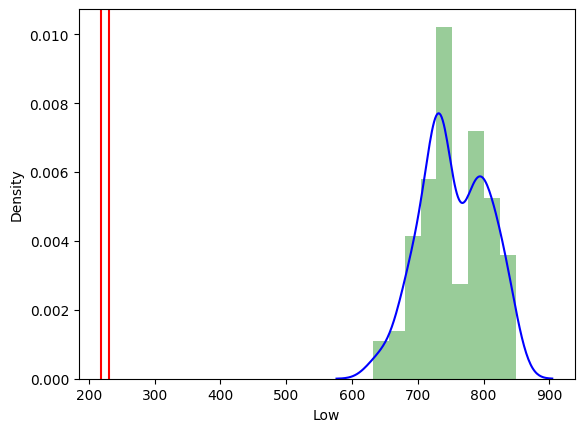

In [21]:
get_pdf_probability(dataset["Low"],219,230)

In [22]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()

C:\Users\Vino Nandu\AppData\Local\Temp\ipykernel_11968\4109782476.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


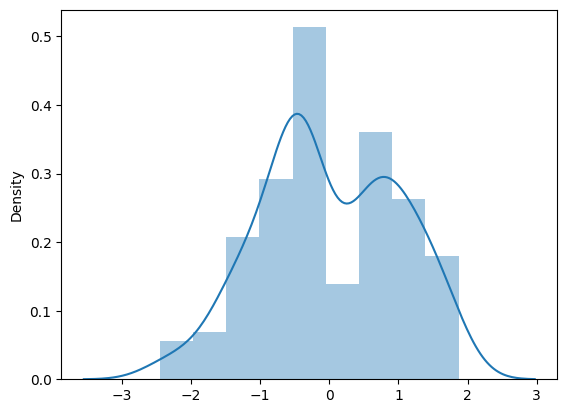

In [23]:
stdNBgraph(dataset["Low"])

In [24]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [25]:
freqTable("Low",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,631.870052,1,0.666667,0.666667
1,635.092848,1,0.666667,1.333333
2,647.695721,1,0.666667,2.000000
3,649.379182,1,0.666667,2.666667
4,661.212331,1,0.666667,3.333333
...,...,...,...,...
145,696.636141,1,0.666667,97.333333
146,701.764129,1,0.666667,98.000000
147,705.392389,1,0.666667,98.666667
148,715.987077,1,0.666667,99.333333


In [26]:
freqTable("High",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,641.923417,1,0.666667,0.666667
1,649.138655,1,0.666667,1.333333
2,657.075644,1,0.666667,2.000000
3,663.761740,1,0.666667,2.666667
4,680.164595,1,0.666667,3.333333
...,...,...,...,...
145,705.247361,1,0.666667,97.333333
146,713.906871,1,0.666667,98.000000
147,720.824825,1,0.666667,98.666667
148,725.082072,1,0.666667,99.333333


In [27]:
fh=freqTable("High",dataset)

In [28]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,641.923417,1,0.666667,0.666667
1,649.138655,1,0.666667,1.333333
2,657.075644,1,0.666667,2.000000
3,663.761740,1,0.666667,2.666667
4,680.164595,1,0.666667,3.333333
...,...,...,...,...
145,705.247361,1,0.666667,97.333333
146,713.906871,1,0.666667,98.000000
147,720.824825,1,0.666667,98.666667
148,725.082072,1,0.666667,99.333333


In [29]:
fhs=fh[fh["Frequency"]==2]["Unique_Values"].sort_values(ascending=False)

In [30]:
fhs

Series([], Name: Unique_Values, dtype: float64)